# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
from scipy.optimize import curve_fit

In [3]:
from ase.eos import EquationOfState, birchmurnaghan

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [5]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [6]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

<AxesSubplot:ylabel='Frequency'>

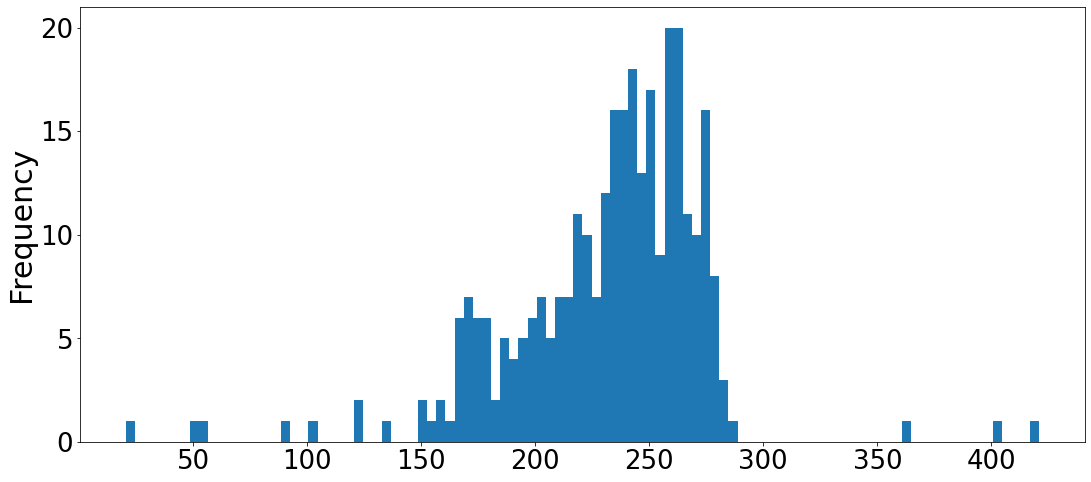

In [7]:
PBS.query('B0>0').B0.plot.hist(bins=100)

In [8]:
PBS[PBS.index.str.contains('R')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Mo_sv,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Fe_pv,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482


## Investigate ev-curves

In [9]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True
if not os.path.exists(fittedcurvesloc) and not force:
    if not os.path.exists(evcurvesloc) and not force:
        print('redoing')
        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

In [10]:
EVcurves[EVcurves.index.str.contains('R')]

Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [11]:
Mo_R = 'Mo_sv53.R.NM'

In [12]:
Fe_R = 'Fe_pv53.R.NM'

In [13]:
x = EVcurves[Fe_R]['xc=PBE-PAW.E=450.dk=0.020']['evcurve']['V']
y = EVcurves[Fe_R]['xc=PBE-PAW.E=450.dk=0.020']['evcurve']['E']

In [14]:
V0 = np.mean(x)

In [15]:
E0 = np.min(y)

In [16]:
V0

10.450377358499999

In [17]:
PBS.loc[Fe_R].B

'274.081057 GPa '

In [18]:
EVcurves[Mo_R]['xc=PBE-PAW.E=450.dk=0.020']

{'evcurve': {'V': [16.7044056604,
   16.6229207547,
   16.5414358491,
   16.4599509434,
   16.3784660377,
   16.2969811321,
   16.2154962264,
   16.1340113208,
   16.0525264151,
   15.9710415094,
   15.8895566038],
  'E': [-10.6186743396,
   -10.62113,
   -10.623034717,
   -10.6243733962,
   -10.6251328302,
   -10.6252992453,
   -10.6248528302,
   -10.6237816981,
   -10.6220664151,
   -10.6196932075,
   -10.6166449057]},
 'ev_fit_results': {'E_murn': -8.146282,
  'V_murn': 10.67006,
  'B_murn': 274.796406,
  'Bdev_murn': 4.678697},
 'r2': 0.0,
 'fit': [-10.6222439623, 0, 0, 16.2969811321],
 'IsGood': False}

In [19]:
results, pcov = curve_fit(birchmurnaghan, x, y, [-8, 10, 270, 4.5] )

In [20]:
results

array([-8.01850773,  1.71099833,  4.53306853, 10.49682001])

In [21]:
pcov

array([[ 8.92675489e-13, -5.16935671e-10,  2.64348029e-08,
        -1.19035223e-11],
       [-5.16935671e-10,  5.41274924e-07, -3.48841170e-05,
         1.48979849e-08],
       [ 2.64348029e-08, -3.48841170e-05,  4.28422734e-03,
        -2.80012838e-06],
       [-1.19035223e-11,  1.48979849e-08, -2.80012838e-06,
         2.52416718e-09]])

In [22]:
e = birchmurnaghan(x, *results)

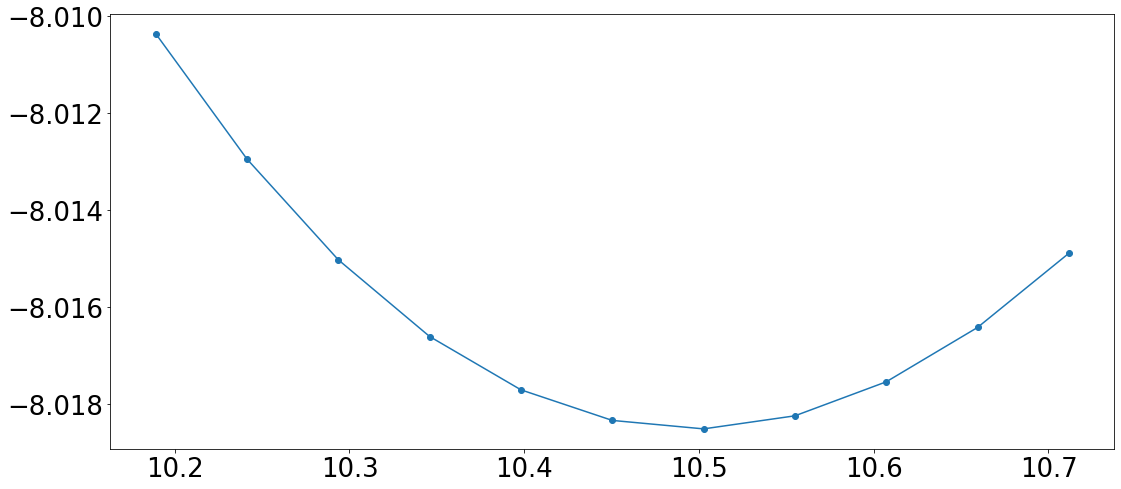

In [23]:
plt.scatter(x, y)
plt.plot(x, e)

In [24]:
indexofgoodsamples = []
for index, data in EVcurves.items():
    for params, evcurve in data.items():
        if  evcurve['IsGood']:
            indexofgoodsamples.append(index)
indexofgoodsamples = pd.Index(indexofgoodsamples)

In [25]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[EVcurves.index.difference(indexofgoodsamples)]

In [26]:
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

In [27]:
BadBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.404611,0.404611,0.404611
Fe_pv10Mo_sv14.C36-ABBBA.FM,bulk C36-ABBBA.FM,13.975813 A,-9.446499,-157.020416 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.371520,0.371520,0.371520
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.403061,0.403061,0.403061
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.353882,0.353882,0.353882
Fe_pv11Mo_sv2.mu-AAABA.FM,bulk mu-AAABA.FM,8.318826 A,-8.453835,-271.520165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,11,2,13,0.846154,0.153846,0.213606,0.213606,0.213606
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,11,2,13,0.846154,0.153846,0.207598,0.207598,0.207598
Fe_pv12Mo_sv12.C36-AAABB.FM,bulk C36-AAABB.FM,14.631811 A,-9.098397,173.539303 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,12,12,24,0.500000,0.500000,0.496375,0.496375,0.496375
Fe_pv12Mo_sv17.chi-BBAB.FM,bulk chi-BBAB.FM,14.233801 A,-9.552726,203.021600 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,12,17,29,0.413793,0.586207,0.272991,0.272991,0.272991
Fe_pv13Mo_sv16.chi-ABAB.FM,bulk chi-ABAB.FM,14.058613 A,-9.439938,-320.617353 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,13,16,29,0.448276,0.551724,0.293401,0.293401,0.293401
Fe_pv14Mo_sv10.C36-AABAB.FM,bulk C36-AABAB.FM,14.643681 A,-8.883492,154.045319 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,14,10,24,0.583333,0.416667,0.488034,0.488034,0.488034


## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [28]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains(r'\..*[UD]+$') ]

## Obtain some info from indexes

In [29]:
Features = Featurizer(GoodBS)

In [30]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.215355,0.215355,0.215355
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667,0.034369,0.034369,0.034369
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333,0.479921,0.479921,0.479921
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586,0.457352,0.457352,0.457352
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231,0.342791,0.326354,0.308107
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.243743,0.224750,0.203664
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,3,4,0.250000,0.750000,0.278101,0.278101,0.278101
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.228782,0.228782,0.228782


## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [31]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [32]:
Target_Class

Fe_pv8Mo_sv22.sigma-BBABB.FM       sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM      sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM           C36
Fe_pv5Mo_sv24.chi-AABB.FM            chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM        R
                                   ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM             mu
Fe_pv8Mo_sv22.sigma-BBABB.NM       sigma
Fe_pv1Mo_sv3.L12-AB3.FM              fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM       sigma
Fe_pv10Mo_sv20.sigma-ABBAB.NM      sigma
Length: 253, dtype: object

In [33]:
Target_Class.to_pickle('Fe-Mo/Descriptors/ClassLabels.pkl')

In [34]:
GoodBS['Phase'] = Target_Class

In [35]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,-9.326032,1.861660,232.915856,13.565978,11.494071,9.446640,20.940711,0.503984,0.496016,0.258079,0.236382,0.212296
std,0.725005,0.345941,34.292351,1.606743,9.026249,7.935386,11.459402,0.283027,0.283027,0.166341,0.165588,0.168636
min,-10.934283,1.000000,91.497861,10.193118,1.000000,0.000000,1.000000,0.000000,0.000000,-0.014908,-0.042122,-0.085007
25%,-9.910610,2.000000,214.842373,12.318164,4.000000,3.000000,13.000000,0.266667,0.266667,0.130572,0.106168,0.080376
50%,-9.307695,2.000000,240.023940,13.381329,10.000000,8.000000,24.000000,0.500000,0.500000,0.236786,0.210457,0.186462
75%,-8.827752,2.000000,259.195265,14.806728,16.000000,14.000000,30.000000,0.733333,0.733333,0.366915,0.351565,0.314326
max,-7.780040,2.000000,287.396036,16.550514,56.000000,44.000000,56.000000,1.000000,1.000000,0.721529,0.721511,0.721511


# some E-V curves, good and bad

In [36]:
sample_bad_index = BadBS.sample(n=5).index.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [37]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [38]:
sample_bad

Fe_pv9Mo_sv4.mu-AAABB.FM       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv5Mo_sv8.mu-ABBAA.FM       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv14Mo_sv10.C36-AABAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv8.C36-ABBAA.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv14.C36-BABBA.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R.NM                   {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [39]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [40]:
sample_bad_r2 = R2[sample_bad.index]

In [41]:
sample_bad_fit = Fits[sample_bad.index]

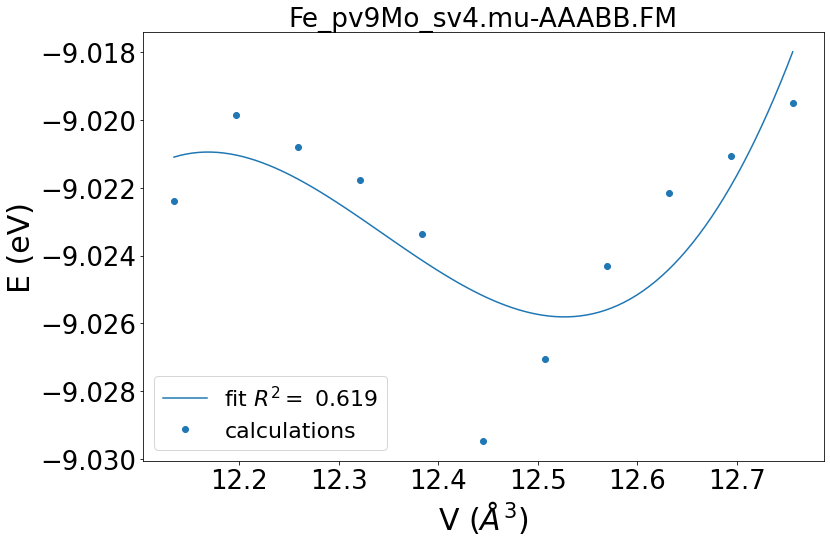

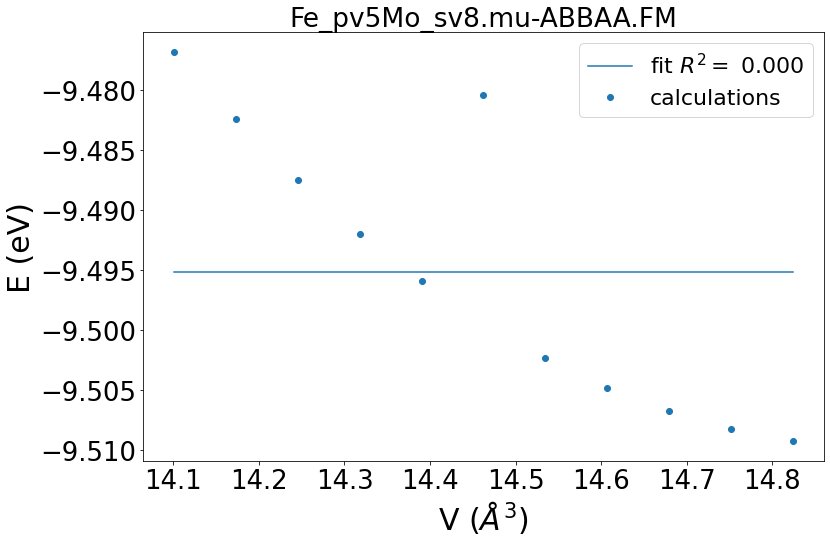

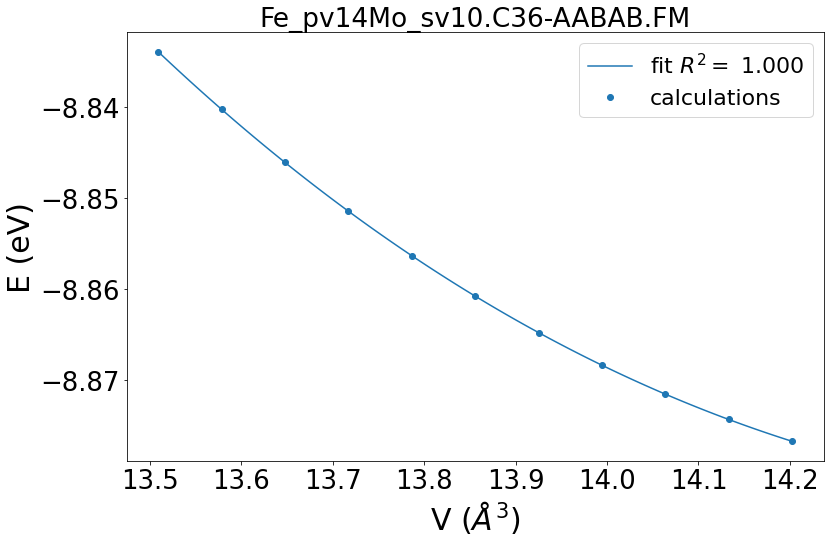

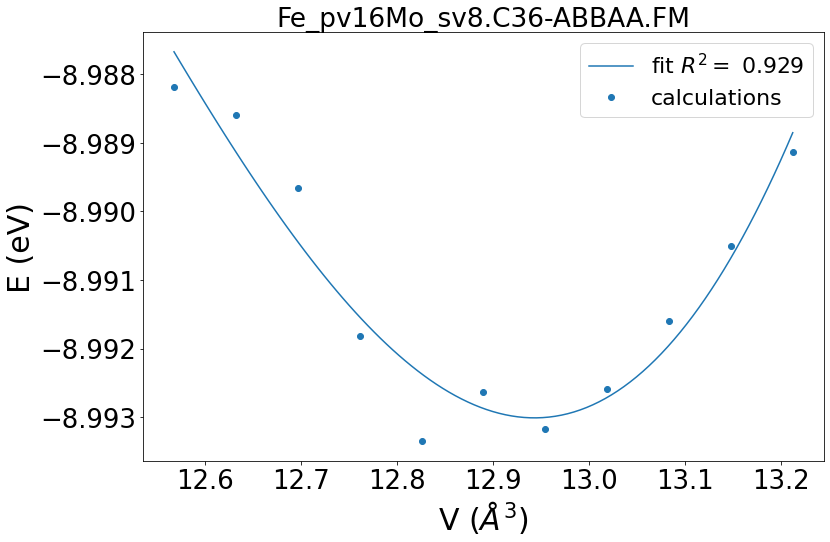

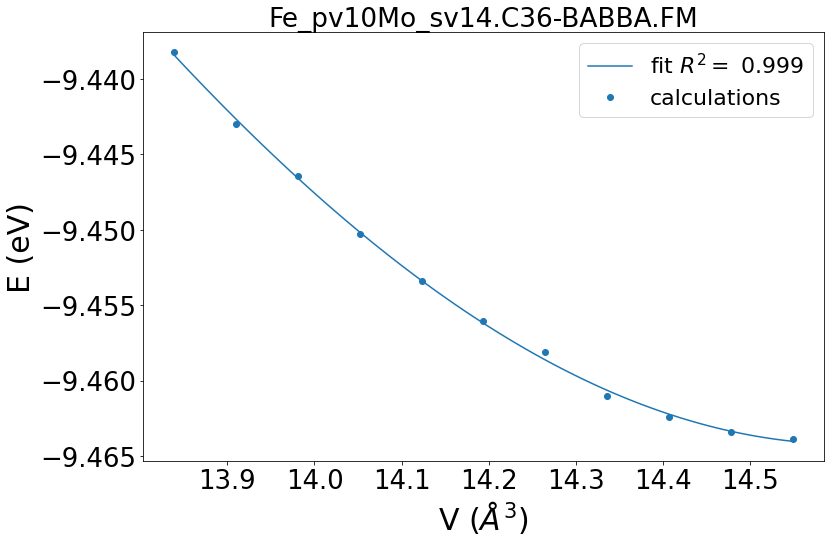

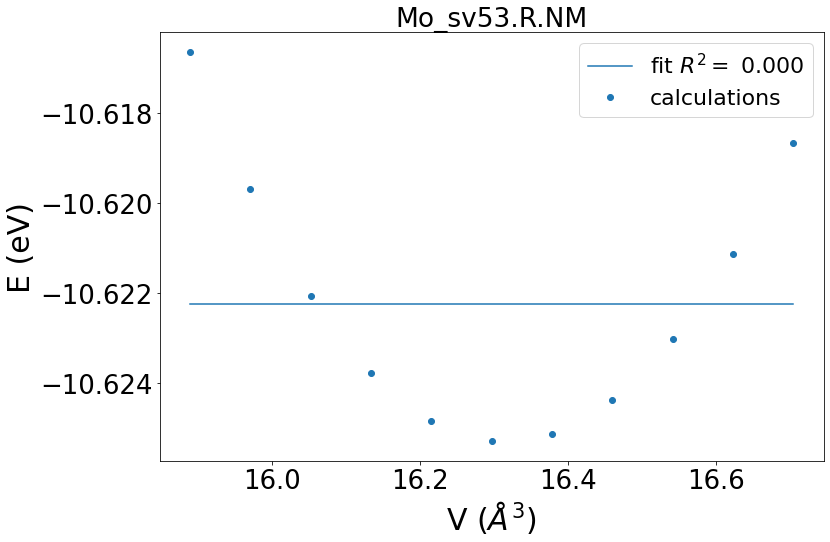

In [42]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

In [43]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [44]:
sample_good

Fe_pv4Mo_sv25.chi-BABB.NM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv4.C36-ABAAA.FM       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv10.sigma-BAAAB.FM    {'xc=PBE-PAW.E=450.dk=0.019': {'evcurve': {'V'...
Fe_pv4Mo_sv9.mu-BBBAA.FM         {'xc=PBE-PAW.E=450.dk=0.019': {'evcurve': {'V'...
Fe_pv8Mo_sv5.mu-BABBA.NM         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [45]:
Goodness[sample_good.index]

Fe_pv4Mo_sv25.chi-BABB.NM        {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv20Mo_sv4.C36-ABAAA.FM       {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv20Mo_sv10.sigma-BAAAB.FM    {'xc=PBE-PAW.E=450.dk=0.019': True}
Fe_pv4Mo_sv9.mu-BBBAA.FM         {'xc=PBE-PAW.E=450.dk=0.019': True}
Fe_pv8Mo_sv5.mu-BABBA.NM         {'xc=PBE-PAW.E=450.dk=0.020': True}
dtype: object

In [46]:
sample_good_r2 = R2[sample_good.index]

In [47]:
sample_good_fit = Fits[sample_good.index]

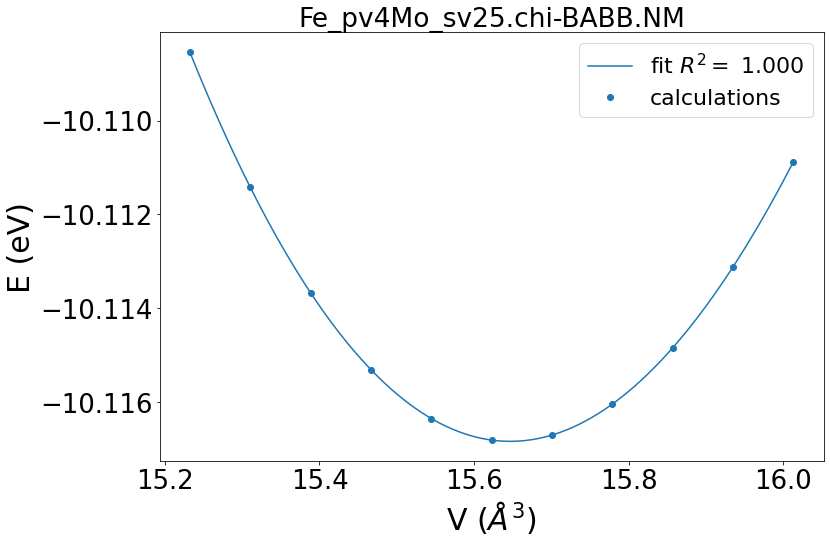

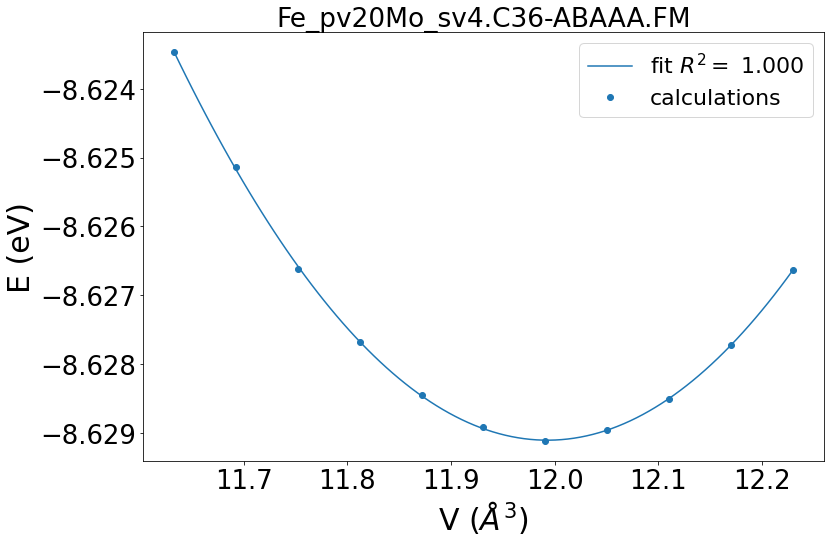

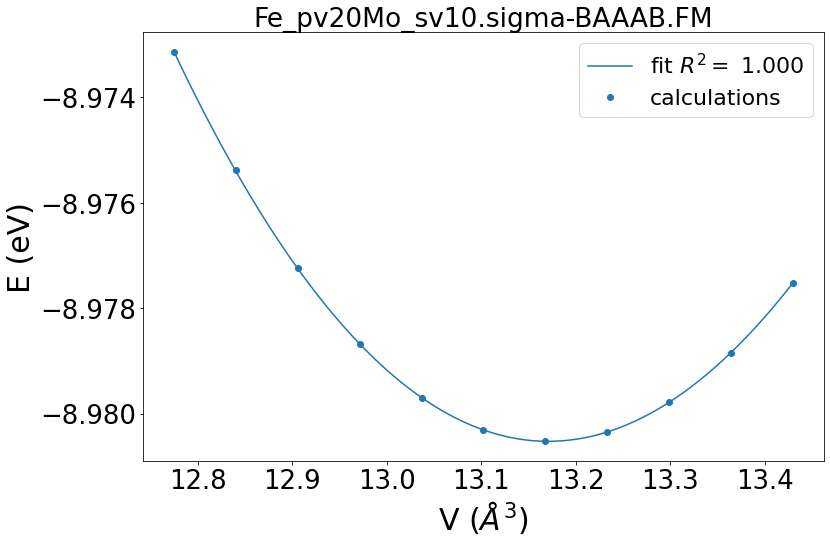

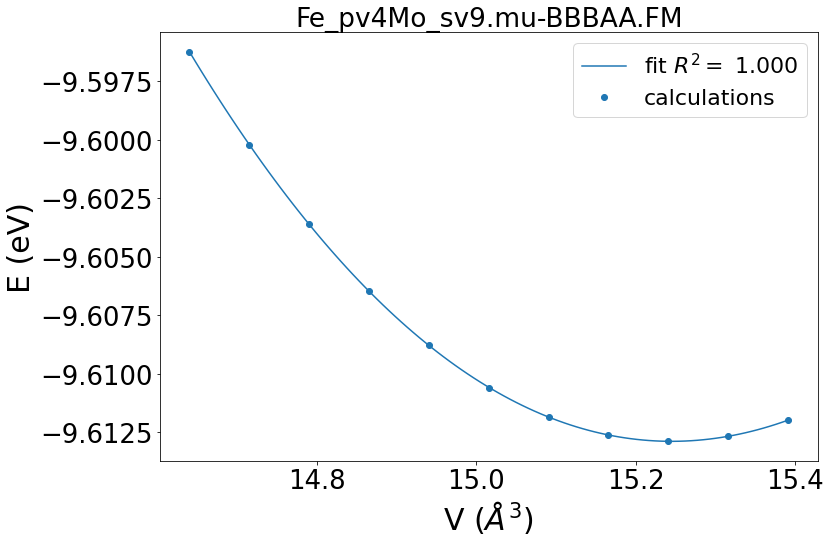

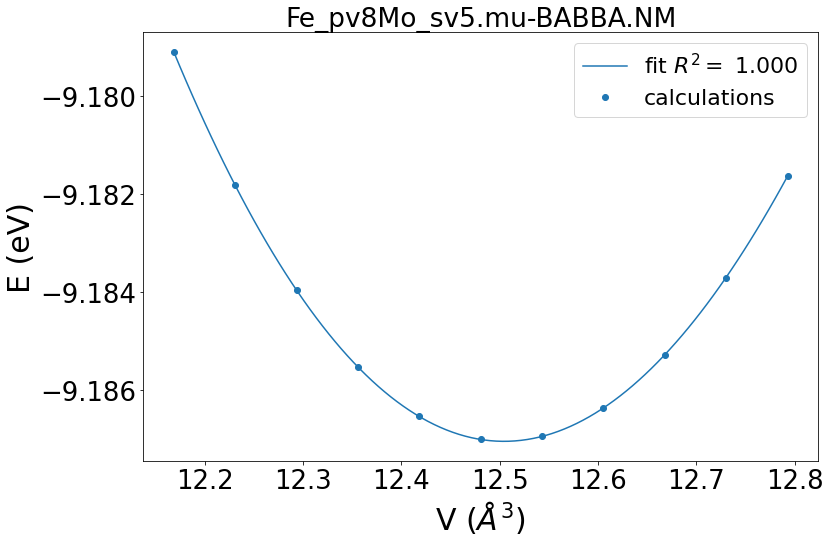

In [48]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

still high and low B0s

<AxesSubplot:>

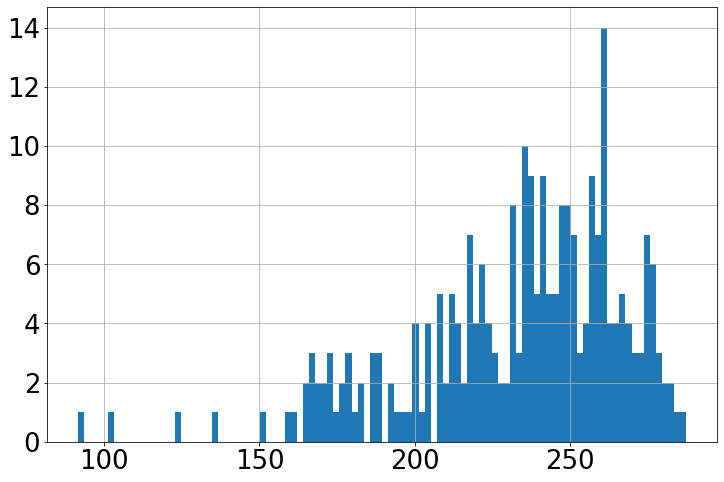

In [49]:
GoodBS.B0.hist(bins=100)

In [50]:
GoodBS.query('nelem == 1').B0.idxmin()

'Fe_pv8.A15.FM'

In [51]:
GoodBS.query('nelem == 1').B0.idxmax()

'Fe_pv2.hcp.NM'

In [52]:
sample_max_B0 = GoodBS.query('nelem == 1').B0.idxmax()

In [53]:
sample_min_B0 = GoodBS.query('nelem == 1').B0.idxmin()

In [54]:
sample_min_B0

'Fe_pv8.A15.FM'

In [55]:
GoodBS.B0[sample_min_B0]

91.497861

In [56]:
sample_max_B0

'Fe_pv2.hcp.NM'

In [57]:
GoodBS.B0[sample_max_B0]

287.396036

In [58]:
selection = ((GoodBS.B0>=GoodBS.B0[sample_min_B0]) & (GoodBS.B0<=GoodBS.B0[sample_max_B0]))

In [59]:
selection.sum()

253

In [60]:
selection_stricter = ((GoodBS.B0>1.1*GoodBS.B0[sample_min_B0]) & (GoodBS.B0<0.90*GoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [61]:
selection_stricter

Fe_pv8Mo_sv22.sigma-BBABB.FM        True
Fe_pv10Mo_sv20.sigma-ABBAB.FM       True
Fe_pv4Mo_sv20.C36-ABBBB.FM          True
Fe_pv5Mo_sv24.chi-AABB.FM           True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM     True
                                   ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM           True
Fe_pv8Mo_sv22.sigma-BBABB.NM        True
Fe_pv1Mo_sv3.L12-AB3.FM             True
Fe_pv8Mo_sv22.sigma-BBBBA.FM        True
Fe_pv10Mo_sv20.sigma-ABBAB.NM      False
Name: B0, Length: 253, dtype: bool

In [63]:
samples_wrong_b0 = GoodBS[~selection].index

In [64]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

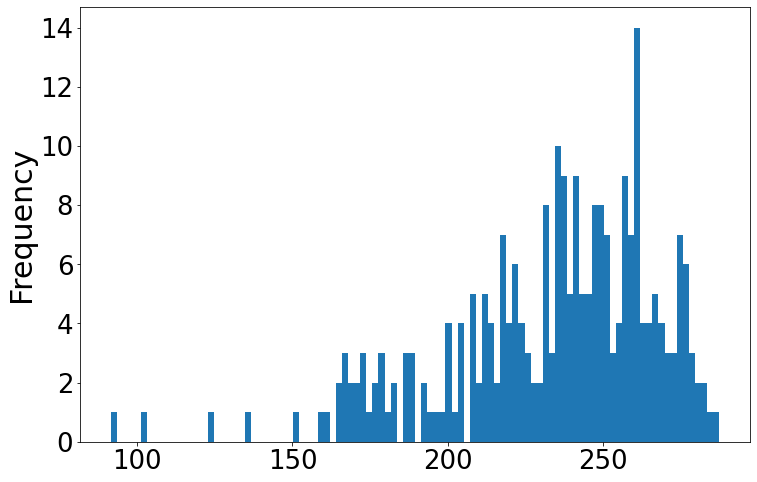

In [65]:
GoodBS.B0.plot.hist(bins=100)

In [66]:
samples_wrong_b0

Index([], dtype='object')

In [67]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [68]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [69]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [70]:
curve_wrong_b0

Series([], dtype: object)

In [71]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [72]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [73]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [74]:
curve_low_b0 = EVcurves[samples_low_b0]

In [75]:
r2_low_b0 = R2[samples_low_b0]

In [76]:
fits_low_b0 = Fits[samples_low_b0]

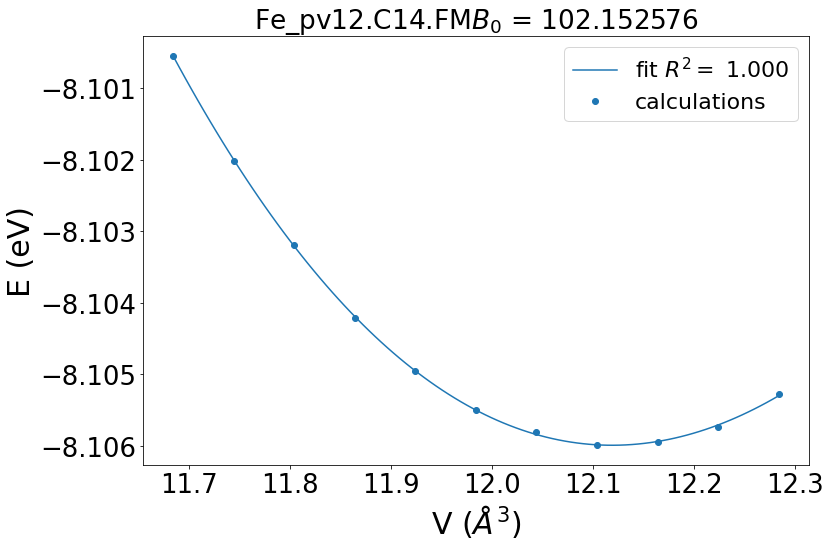

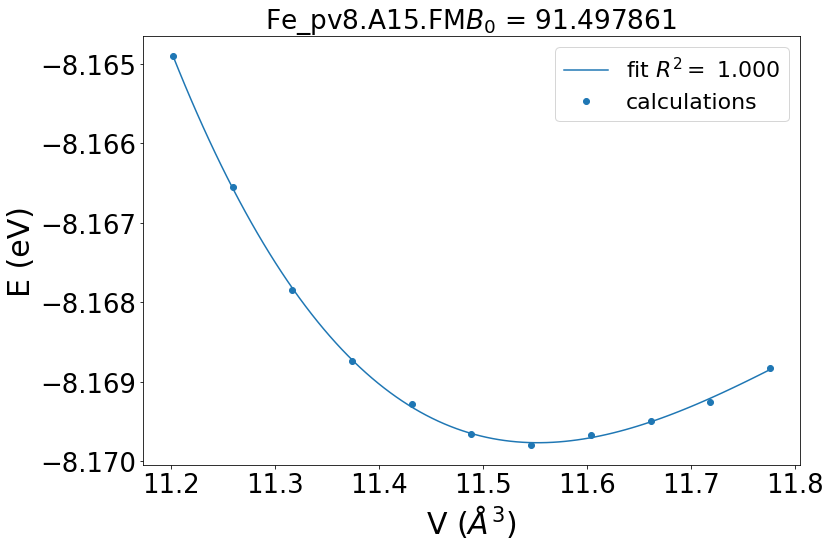

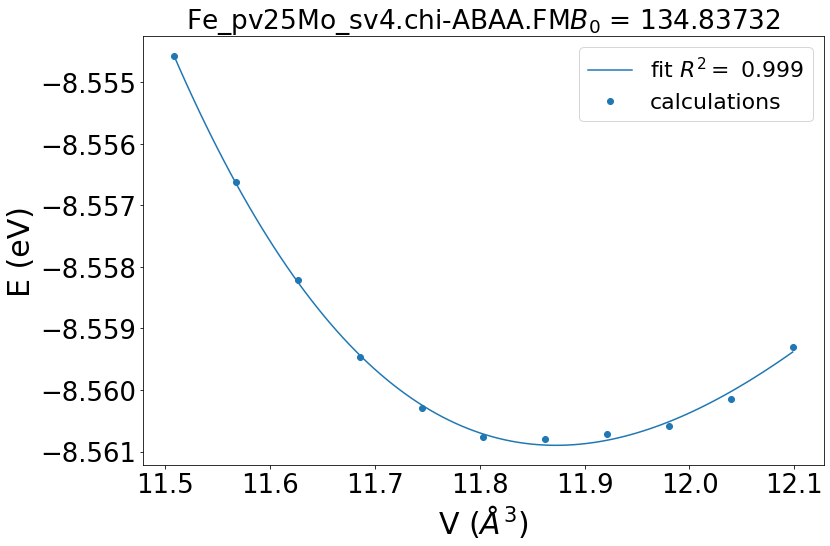

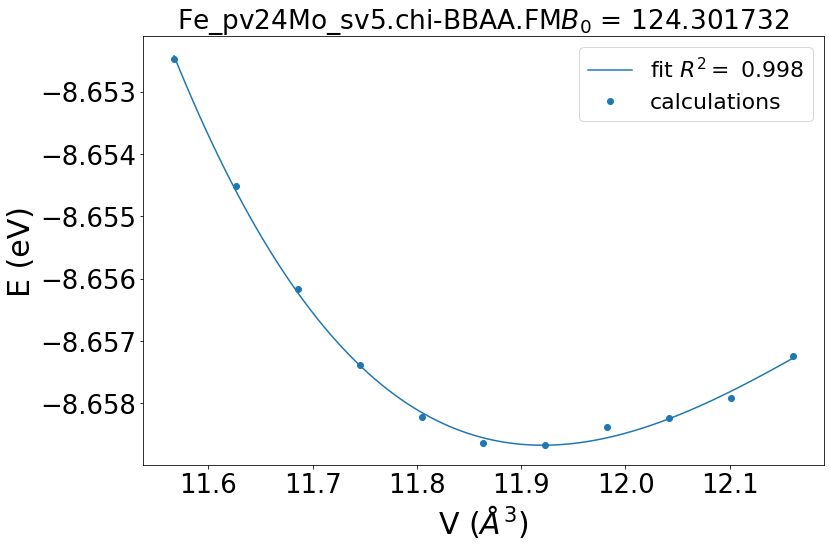

In [77]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Save for later use 

In [ ]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

In [ ]:
GoodBS.B0.hist(bins=100)

In [ ]:
PBS